In [1]:
!pip install pandas matplotlib seaborn

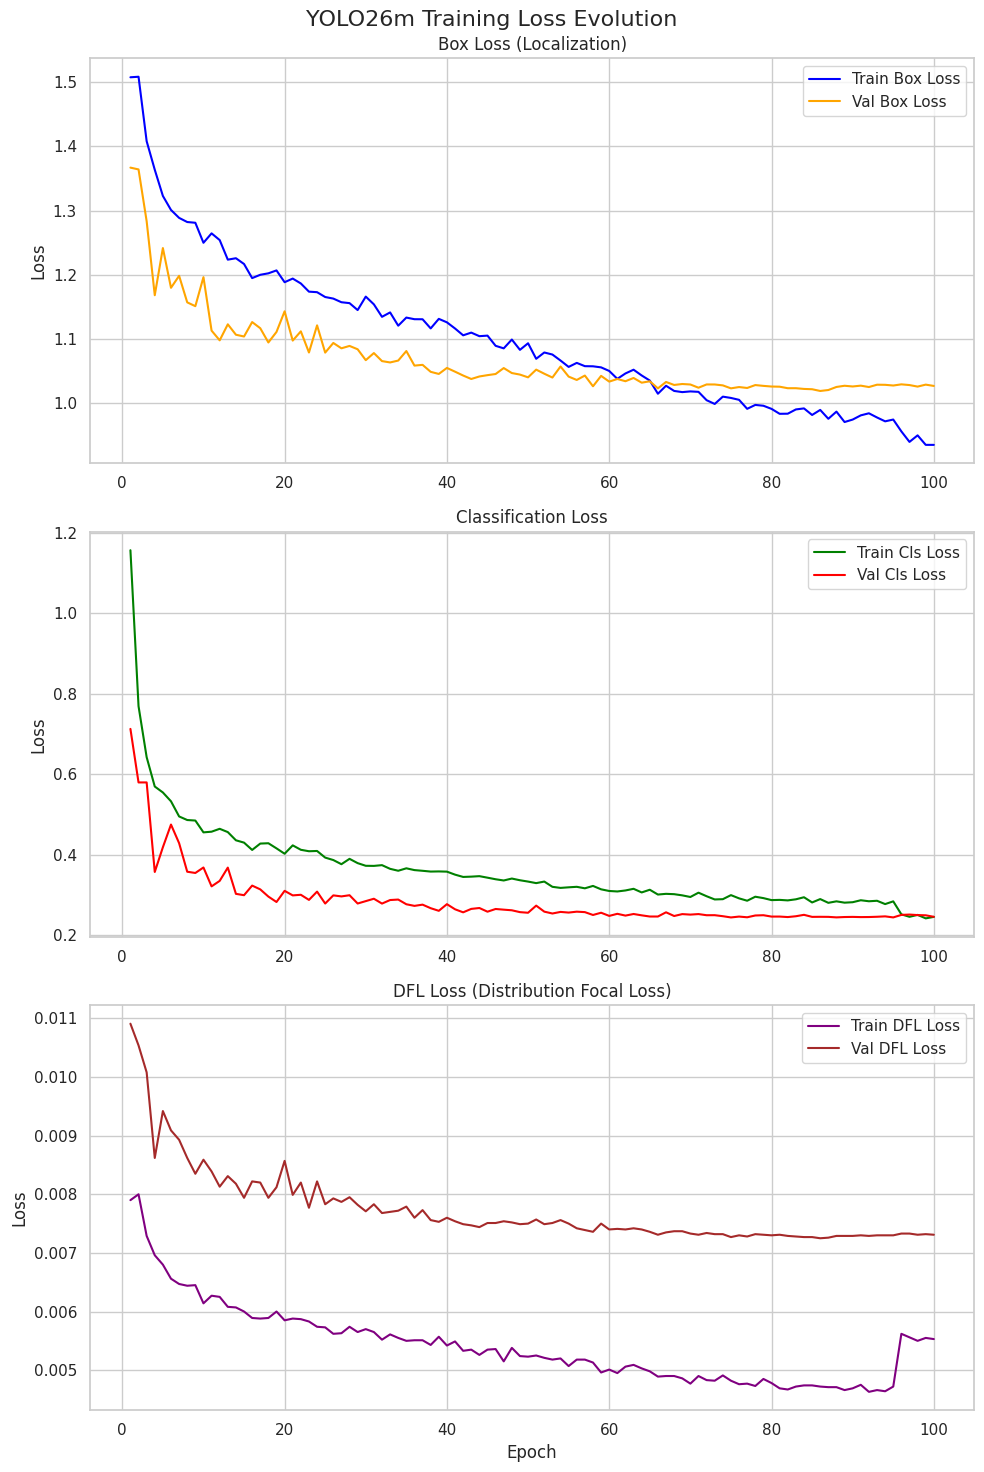

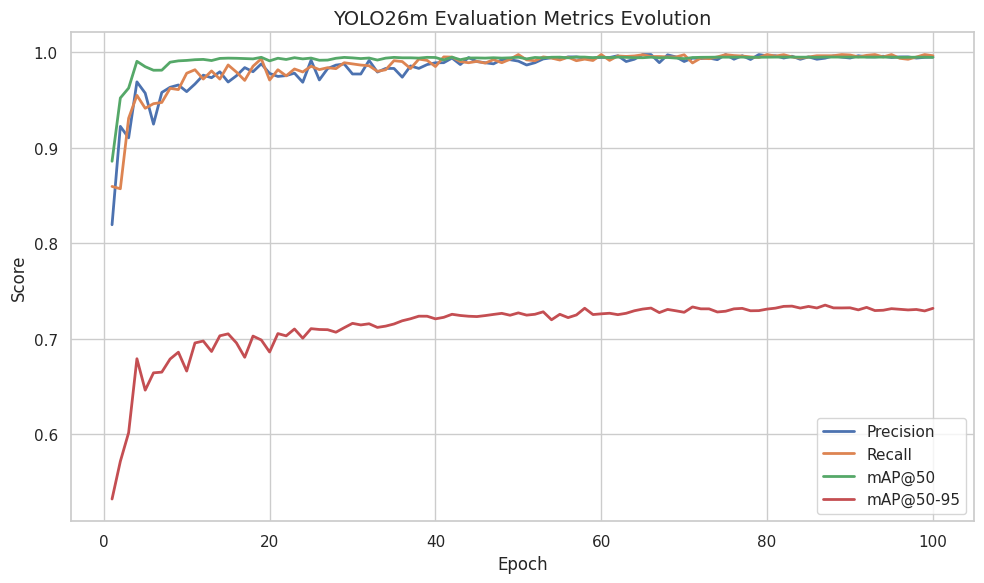

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('yolo-result.csv')

# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Vẽ biểu đồ Loss (Box Loss, Cls Loss, DFL Loss)
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle('YOLO26m Training Loss Evolution', fontsize=16)

# Box Loss
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='orange')
axes[0].set_title('Box Loss (Localization)')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Classification Loss
axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss', color='green')
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss', color='red')
axes[1].set_title('Classification Loss')
axes[1].set_ylabel('Loss')
axes[1].legend()

# DFL Loss
axes[2].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss', color='purple')
axes[2].plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss', color='brown')
axes[2].set_title('DFL Loss (Distribution Focal Loss)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()
plt.savefig('yolo_loss_plots.png', dpi=300)
plt.show()

# 3. Vẽ biểu đồ Metrics (Precision, Recall, mAP)
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2)
ax2.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2)
ax2.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', linewidth=2)
ax2.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', linewidth=2)
ax2.set_title('YOLO26m Evaluation Metrics Evolution', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
plt.tight_layout()
plt.savefig('yolo_metrics_plots.png', dpi=300)
plt.show()